# Stage 4: Model Training (Random Forest + XGBoost)

Train ensemble models with sample weights from Chapter 4 and the purged K-fold CV from Chapter 7. Outputs `model_rf.pkl`, `model_xgb.pkl`, and `cv_results.parquet`.

In [1]:
import sys, os, pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score
from sklearn.base import clone
from xgboost import XGBClassifier

sys.path.append('../')
from src.cross_validation import PurgedKFold
from src.modelling import train_and_evaluate

plt.style.use('seaborn-v0_8-darkgrid')
RNG = 42

## 1. Load modelling dataset

In [2]:
dataset = pd.read_parquet('../data/processed/nvda_modelling_dataset.parquet')

X = dataset.drop(columns=['label', 'weight', 't1'])
y = dataset['label'].astype(int)              # -1 / +1
sample_weight = dataset['weight']
t1 = dataset['t1']

# XGBoost expects labels in [0, num_class), so remap -1/+1 -> 0/1.
y_xgb = (y == 1).astype(int)

print(f'X shape: {X.shape}')
print(f'features: {list(X.columns)}')
print(f'label distribution:\n{y.value_counts().sort_index()}')

X shape: (171, 17)
features: ['ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'momentum_12_1', 'rsi_14', 'vol_20d', 'vol_50d', 'log_dollar_volume', 'volume_ratio', 'corwin_schultz_spread', 'bekker_parkinson_vol', 'amihud_illiquidity', 'roll_spread', 'shannon_entropy', 'lempel_ziv_complexity', 'fracdiff']
label distribution:
label
-1    74
 1    97
Name: count, dtype: int64


## 2. Define models

In [3]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=10,
    class_weight='balanced_subsample',
    random_state=RNG,
    n_jobs=-1,
)

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RNG,
    eval_metric='logloss',
    n_jobs=-1,
)

rf, xgb

(RandomForestClassifier(class_weight='balanced_subsample', max_depth=5,
                        min_samples_leaf=10, n_estimators=500, n_jobs=-1,
                        random_state=42),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.05, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=3, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=500, n_jobs=-1,
               num_parallel_tree=None, ...))

## 3. Purged 5-fold CV with sample weights

`PurgedKFold` removes any training event whose label window overlaps the test fold (or sits inside the embargo window after it).

In [4]:
pkf = PurgedKFold(n_splits=5, t1=t1, pct_embargo=0.01)

rf_results = train_and_evaluate(rf, X, y, sample_weight, cv=pkf, scoring='accuracy')
xgb_results = train_and_evaluate(xgb, X, y_xgb, sample_weight, cv=pkf, scoring='accuracy')

print(f"RF  accuracy: {rf_results['mean_score']:.4f} +/- {rf_results['std_score']:.4f}")
print(f"XGB accuracy: {xgb_results['mean_score']:.4f} +/- {xgb_results['std_score']:.4f}")

RF  accuracy: 0.5376 +/- 0.0934
XGB accuracy: 0.5612 +/- 0.0605


## 4. Per-fold scores

In [5]:
fold_scores = pd.DataFrame({
    'RF':  rf_results['fold_scores'].values,
    'XGB': xgb_results['fold_scores'].values,
}, index=[f'fold_{i+1}' for i in range(pkf.get_n_splits())])
fold_scores

,RF,XGB
fold_1,0.600000,0.600000
fold_2,0.529412,0.529412
fold_3,0.558824,0.529412
fold_4,0.382353,0.500000
fold_5,0.617647,0.647059


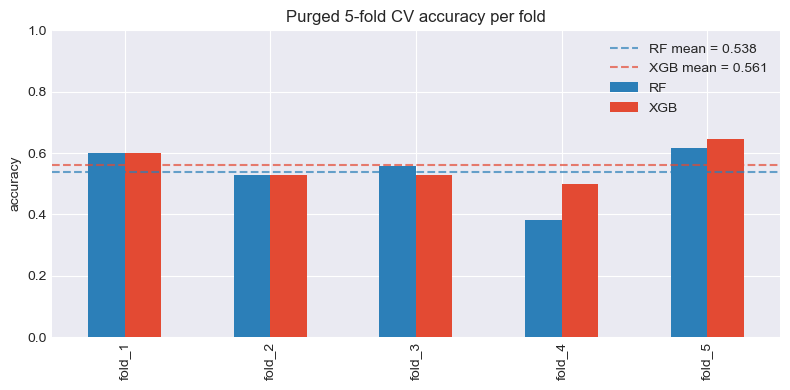

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
fold_scores.plot(kind='bar', ax=ax, color=['#2c7fb8', '#e34a33'])
ax.axhline(rf_results['mean_score'], color='#2c7fb8', linestyle='--', alpha=0.7,
           label=f"RF mean = {rf_results['mean_score']:.3f}")
ax.axhline(xgb_results['mean_score'], color='#e34a33', linestyle='--', alpha=0.7,
           label=f"XGB mean = {xgb_results['mean_score']:.3f}")
ax.set_ylabel('accuracy')
ax.set_title('Purged 5-fold CV accuracy per fold')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Confusion matrix on a representative fold

Pick the fold whose accuracy is closest to the RF mean, refit, and plot the confusion matrix on that test fold.

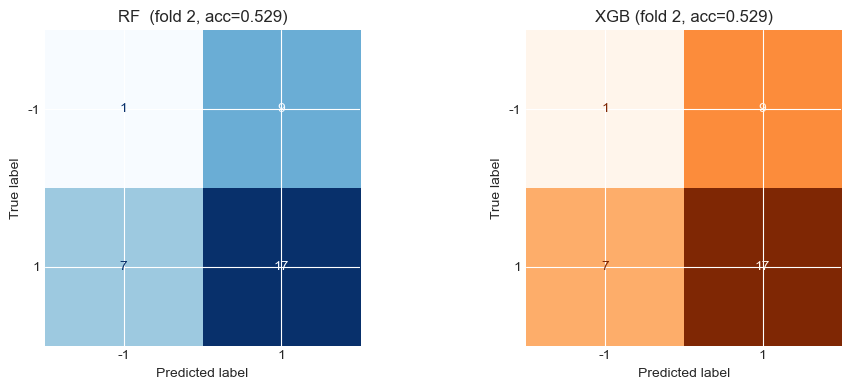

In [7]:
def representative_fold(scores):
    diffs = np.abs(scores.values - scores.mean())
    return int(np.argmin(diffs))

fold_idx = representative_fold(rf_results['fold_scores'])
splits = list(pkf.split(X, y))
train_idx, test_idx = splits[fold_idx]

X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
y_xgb_tr, y_xgb_te = y_xgb.iloc[train_idx], y_xgb.iloc[test_idx]
sw_tr = sample_weight.iloc[train_idx].values

rf_fold = clone(rf).fit(X_tr, y_tr, sample_weight=sw_tr)
xgb_fold = clone(xgb).fit(X_tr, y_xgb_tr, sample_weight=sw_tr)

rf_pred = rf_fold.predict(X_te)
xgb_pred_01 = xgb_fold.predict(X_te)
xgb_pred = np.where(xgb_pred_01 == 1, 1, -1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_te, rf_pred, labels=[-1, 1]), display_labels=[-1, 1]
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'RF  (fold {fold_idx + 1}, acc={accuracy_score(y_te, rf_pred):.3f})')

ConfusionMatrixDisplay(
    confusion_matrix(y_te, xgb_pred, labels=[-1, 1]), display_labels=[-1, 1]
).plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title(f'XGB (fold {fold_idx + 1}, acc={accuracy_score(y_te, xgb_pred):.3f})')

plt.tight_layout()
plt.show()

## 6. Comparison table

In [8]:
comparison = pd.DataFrame({
    'mean_acc':  [rf_results['mean_score'], xgb_results['mean_score']],
    'std_acc':   [rf_results['std_score'],  xgb_results['std_score']],
    'min_acc':   [rf_results['fold_scores'].min(), xgb_results['fold_scores'].min()],
    'max_acc':   [rf_results['fold_scores'].max(), xgb_results['fold_scores'].max()],
}, index=['RandomForest', 'XGBoost'])
comparison.round(4)

,mean_acc,std_acc,min_acc,max_acc
RandomForest,0.5376,0.0934,0.3824,0.6176
XGBoost,0.5612,0.0605,0.5000,0.6471


## 7. Fit final models on full data and persist

These full-data models are used downstream by Stage 6 (feature importance) and Stage 7 (meta-labeling / bet sizing).

In [9]:
rf_final = rf_results['fitted_clf']
xgb_final = xgb_results['fitted_clf']

models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

with open(os.path.join(models_dir, 'model_rf.pkl'), 'wb') as f:
    pickle.dump(rf_final, f)
with open(os.path.join(models_dir, 'model_xgb.pkl'), 'wb') as f:
    pickle.dump(xgb_final, f)

cv_results_df = fold_scores.copy()
cv_results_df.loc['mean'] = comparison['mean_acc'].values
cv_results_df.loc['std']  = comparison['std_acc'].values
cv_results_df.to_parquet('../data/processed/cv_results.parquet')

print('Saved:')
print('  ../models/model_rf.pkl')
print('  ../models/model_xgb.pkl')
print('  ../data/processed/cv_results.parquet')

Saved:
  ../models/model_rf.pkl
  ../models/model_xgb.pkl
  ../data/processed/cv_results.parquet


## 8. Notes and limitations

- Only 171 events after CUSUM + triple-barrier filtering, so absolute accuracy numbers are noisy; the 5-fold std is the headline number to trust, not any single fold.
- Hyperparameters here come from the AFML-prompt recipe; Stage 5 will tune them via `RandomizedSearchCV` against the same `PurgedKFold`.
- Because labels are binary (+1 / -1) after dropping vertical-barrier outcomes upstream, baseline accuracy from majority class is `97 / 171 ≈ 0.567`.